In [4]:
#!/usr/bin/env python
# coding: utf-8

# # Decision Tree Classification on IRIS Dataset
# 
# This notebook demonstrates how to implement a decision tree classifier on the famous IRIS dataset.
# We'll cover:
# 1. Loading and exploring the dataset
# 2. Splitting the data into training and testing sets
# 3. Training a decision tree classifier
# 4. Visualizing the decision tree
# 5. Evaluating the model and printing all parameters

# ## 1. Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import tree
import graphviz
from IPython.display import display

# Set random seed for reproducibility
np.random.seed(42)




In [5]:
# ## 2. Load and explore the IRIS dataset

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for easier exploration
iris_df = pd.DataFrame(data=X, columns=feature_names)
iris_df['target'] = y
iris_df['species'] = iris_df['target'].apply(lambda x: target_names[x])

# Display the first few rows of the dataset
print("First 5 rows of the IRIS dataset:")
print(iris_df.head())

# Basic dataset information
print("\nBasic dataset information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Features: {feature_names}")
print(f"Target classes: {target_names}")
print(f"Class distribution: {np.bincount(y)}")

First 5 rows of the IRIS dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Basic dataset information:
Number of samples: 150
Number of features: 4
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


<Figure size 1200x1000 with 0 Axes>

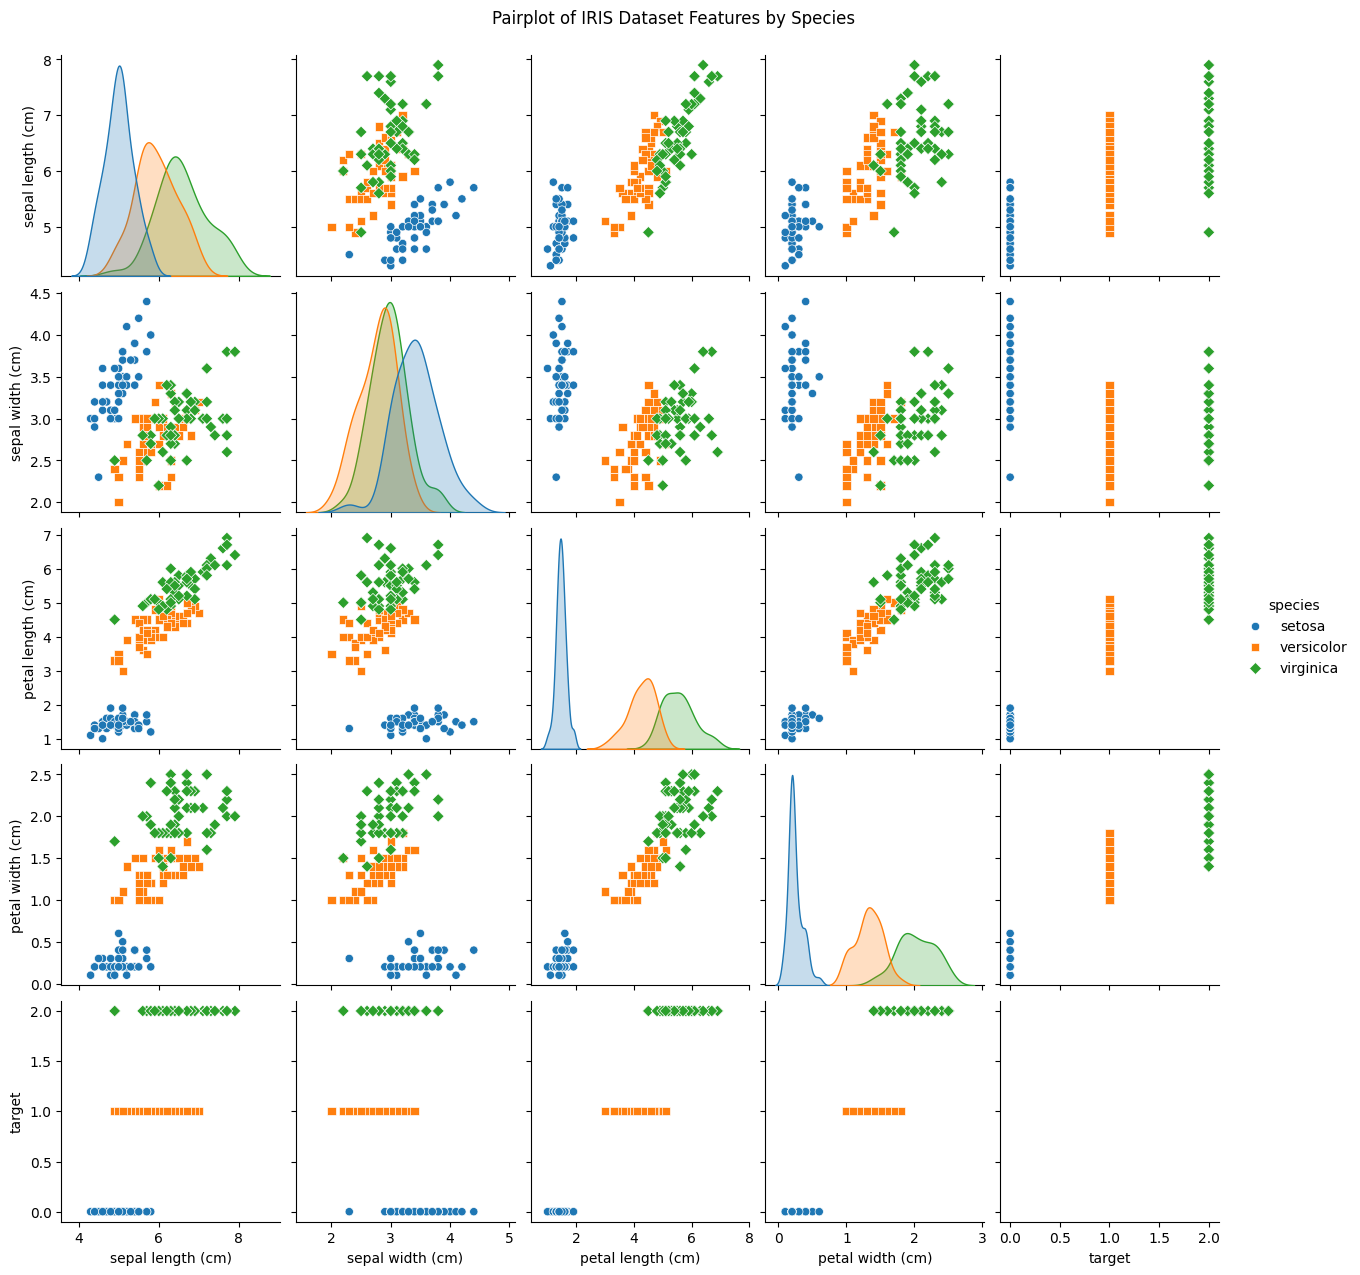

In [6]:
# ## 3. Visualize the dataset

# Pairplot to visualize relationships between features
plt.figure(figsize=(12, 10))
sns.pairplot(iris_df, hue='species', markers=["o", "s", "D"])
plt.suptitle("Pairplot of IRIS Dataset Features by Species", y=1.02)
plt.show()


Training set size: 105 samples
Testing set size: 45 samples


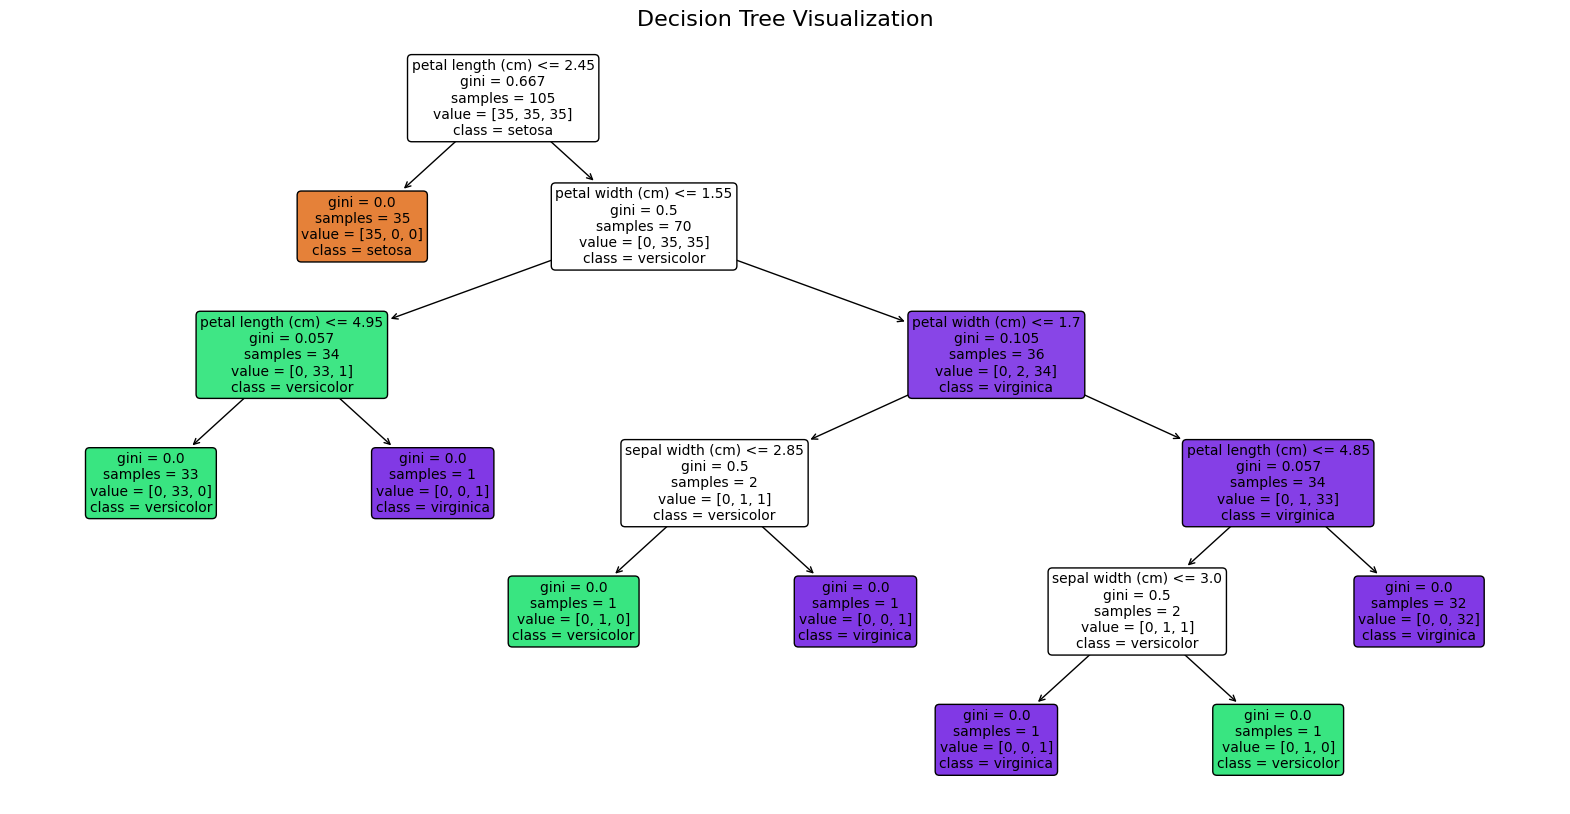

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [7]:



# ## 4. Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# ## 5. Train a Decision Tree Classifier

# Initialize the classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# ## 6. Visualize the Decision Tree

plt.figure(figsize=(20, 10))
tree.plot_tree(dt_classifier, feature_names=feature_names, class_names=target_names, 
               filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization", fontsize=16)
plt.show()

# For a more detailed visualization using graphviz
dot_data = tree.export_graphviz(dt_classifier, out_file=None, 
                                feature_names=feature_names,  
                                class_names=target_names,
                                filled=True, rounded=True,  
                                special_characters=True)
graph = graphviz.Source(dot_data)
# Uncomment to save the visualization as a PDF
# graph.render("iris_decision_tree", format="pdf")
display(graph)



In [8]:
# ## 7. Make predictions and evaluate the model

y_pred = dt_classifier.predict(X_test)

# Print model parameters
print("\nDecision Tree Parameters:")
print(f"Criterion: {dt_classifier.criterion}")
print(f"Splitter: {dt_classifier.splitter}")
print(f"Max Depth: {dt_classifier.max_depth}")
print(f"Min Samples Split: {dt_classifier.min_samples_split}")
print(f"Min Samples Leaf: {dt_classifier.min_samples_leaf}")
print(f"Max Features: {dt_classifier.max_features}")
print(f"Tree Depth: {dt_classifier.get_depth()}")
print(f"Number of Leaves: {dt_classifier.get_n_leaves()}")
print(f"Feature Importances: {dt_classifier.feature_importances_}")

# Print feature importance with feature names
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)




Decision Tree Parameters:
Criterion: gini
Splitter: best
Max Depth: None
Min Samples Split: 2
Min Samples Leaf: 1
Max Features: None
Tree Depth: 5
Number of Leaves: 8
Feature Importances: [0.         0.02857143 0.54117647 0.4302521 ]

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.541176
3   petal width (cm)    0.430252
1   sepal width (cm)    0.028571
0  sepal length (cm)    0.000000



Model Evaluation:
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


Confusion Matrix:


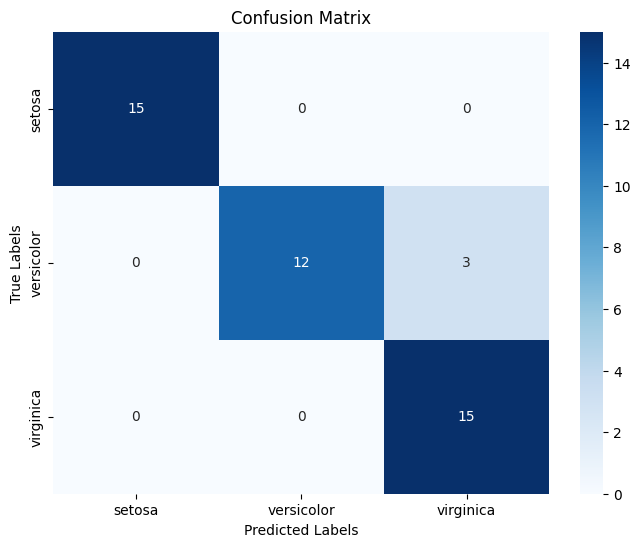

In [9]:
# ## 8. Evaluate model performance

print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()



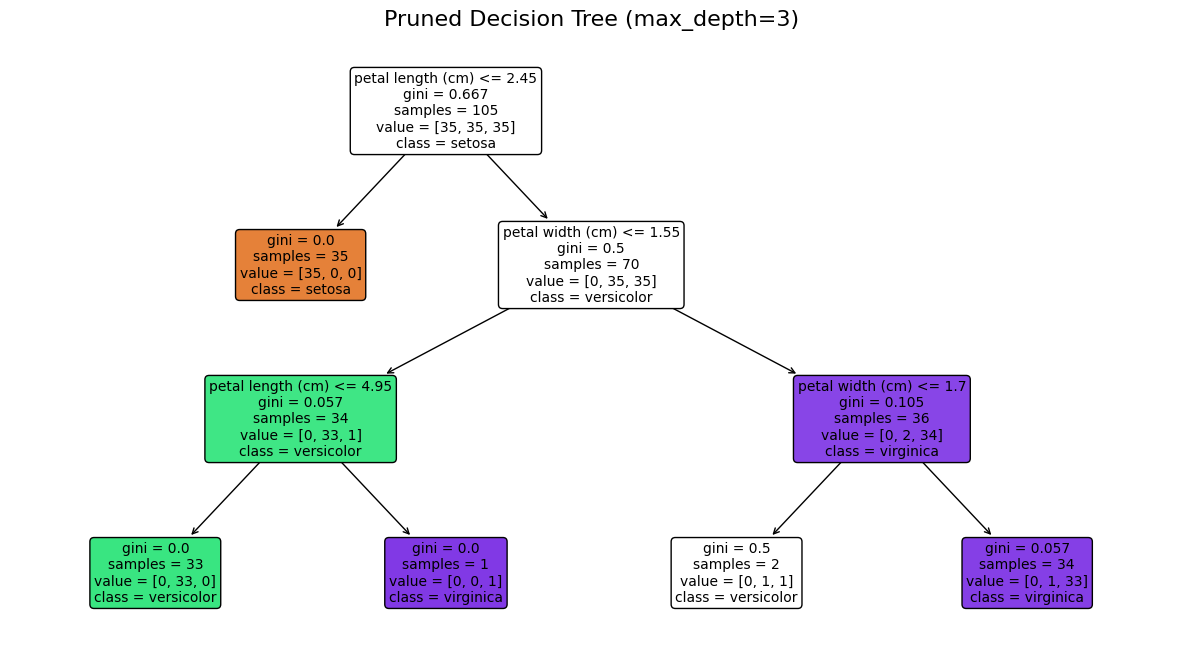


Pruned Decision Tree Evaluation:
Accuracy: 0.9778

Classification Report (Pruned Tree):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [10]:
# ## 9. Try different parameters to improve the model

# Let's create a decision tree with controlled depth to avoid overfitting
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

# Visualize the pruned tree
plt.figure(figsize=(15, 8))
tree.plot_tree(dt_pruned, feature_names=feature_names, class_names=target_names, 
               filled=True, rounded=True, fontsize=10)
plt.title("Pruned Decision Tree (max_depth=3)", fontsize=16)
plt.show()

# Evaluate the pruned model
y_pred_pruned = dt_pruned.predict(X_test)
print("\nPruned Decision Tree Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pruned):.4f}")
print("\nClassification Report (Pruned Tree):")
print(classification_report(y_test, y_pred_pruned, target_names=target_names))



In [11]:
# ## 10. Conclusion

print("\nConclusion:")
print("We have successfully implemented a decision tree classifier on the IRIS dataset.")
print("The model achieved good accuracy in classifying the three species of iris flowers.")
print("We also visualized the decision tree and analyzed feature importance.")
print("The most important features for classification were:", 
      feature_names[np.argmax(dt_classifier.feature_importances_)])


Conclusion:
We have successfully implemented a decision tree classifier on the IRIS dataset.
The model achieved good accuracy in classifying the three species of iris flowers.
We also visualized the decision tree and analyzed feature importance.
The most important features for classification were: petal length (cm)
